# Homework Assignment: Exoplanet Detection Methods

*In this assignment, you will be attempting to model transit and radial velocity data to find the parameters of a (fake) planet. In part 1, you will be modeling this data by hand; in the (optional) part 2, you will be running some code to automatically fit this data.*

# Part 1: Fitting Data By Hand

You are a scientist looking for potential exoplanets around the star HD 1234, an M dwarf with a mass, radius, and equilibrium temperature of 0.2$M_⊙$, 0.2$R_⊙$, and 3100 K. Recently, you have been looking through light curves of the HD 1234, observed with the Transiting Exoplanet Survey Satellite (TESS), and you’ve noticed signals that may appear to be a planet!

Let's load in the data, and plot both the entire light curve (the set of stellar fluxes as a function of time) as well as a zoom-in on a single transit.

In [1]:
# Import the warnings library.
import warnings

# Ignore all warning messages.
warnings.filterwarnings("ignore")

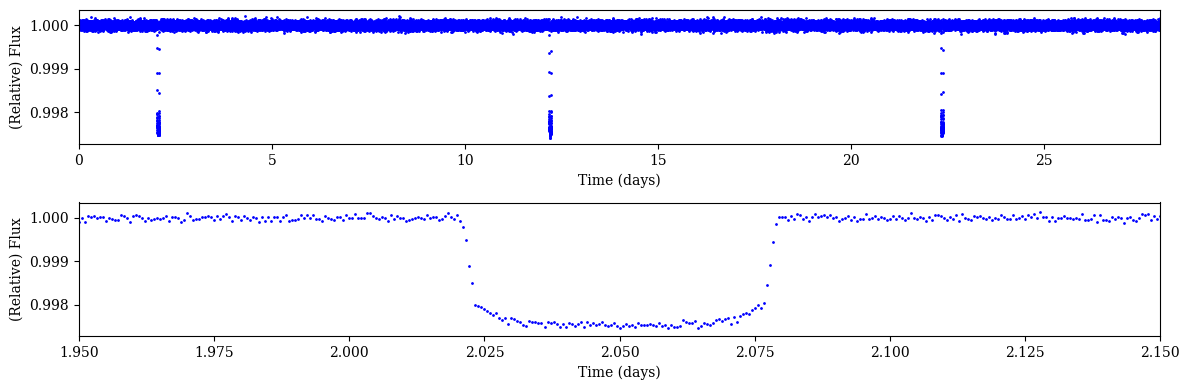

In [2]:
# Import NumPy for numerical operations.
import numpy as np

# Import Matplotlib for plotting.
import matplotlib.pyplot as plt

# Set the font family for all plots to serif.
plt.rcParams["font.family"] = "serif"

# Load the light curve data from the CSV file.
data = np.loadtxt('HD 1234 Light Curve.csv')

# Extract the time values (days) from the first row.
times_lc = data[0]

# Extract the relative flux values from the second row.
flux_lc = data[1]

# Define the measurement uncertainty.
err_lc = 0.00005

# Create a figure with two vertically stacked subplots.
fig, ax = plt.subplots(nrows = 2, figsize = (12, 4))

# Plot the full light curve as a scatter plot.
ax[0].scatter(times_lc, flux_lc, c = 'blue', s = 1)
ax[0].set_xlabel('Time (days)')
ax[0].set_ylabel('(Relative) Flux')
ax[0].set_xlim(0., 28)

# Plot a zoomed-in view of a single transit.
ax[1].scatter(times_lc, flux_lc, c = 'blue', s = 1)
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('(Relative) Flux')
ax[1].set_xlim(1.95, 2.15)

# Adjust the layout for better spacing and display the plots.
plt.tight_layout();

That sure looks like a planetary transit to me! But, of course, it might be a little difficult to figure out how big this planet is, or how close it is to its star it is -- very important things for us as astronomers to know!

But luckily for us, we can use Python packages to model this data. For the light curve data, we're going to be using the ```batman``` package, which you'll need to install: https://lkreidberg.github.io/batman/docs/html/installation.html

Install the package, and then move onto the next cell.

In [3]:
# pip install batman-package

In [4]:
# Import the batman package for modeling exoplanet transit light curves.
import batman

For this assignment, I've written a function that will take in planetary parameters and then model this light curve here. You can see the function below:

In [5]:
# --------------------------------------------------------------------------------------------------
# Parameters of the planet (feel free to change them around and see how the light curve changes!)
# --------------------------------------------------------------------------------------------------
M = 1.0 # the mass of the planet, in Earth masses (note: this should not affect light curves!)
R = 1.05 # the radius of the planet, in Earth radii
P = 10.1 # the period of the planet's orbit, in days
t0 = 2.05 # the epoch of the planet -- meaning the time of the first transit -- in days
inc = 90. # the inclination of the planet, in degrees
e = 0. # the eccentricity of the planet's orbit
w = 0. # the longitude of periastron, in degrees

In [6]:
def model_light_curve():
    # a calculation -- Kepler's third law, then converting to units of stellar radii
    a = np.cbrt(6.67e-11 * (0.2 * 1.989e30) * np.power(P * 86400., 2) / (4 * np.pi * np.pi)) / 1.39e8
    
    params = batman.TransitParams()
    params.t0 = t0                       #time of inferior conjunction
    params.per = P                      #orbital period
    params.rp = R * 0.0458                      #planet radius (in units of stellar radii)
    params.a = a  #semi-major axis (in units of stellar radii)
    params.inc = inc                     #orbital inclination (in degrees)
    params.ecc = e                      #eccentricity
    params.w = w                       #longitude of periastron (in degrees)
    params.u = [0.1, 0.3]                #limb darkening coefficients [u1, u2]
    params.limb_dark = "quadratic"       #limb darkening model

    t = np.arange(0, 28, (2 / 3600.))
    m = batman.TransitModel(params, t)    #initializes model
    flux = m.light_curve(params)
    return t, flux

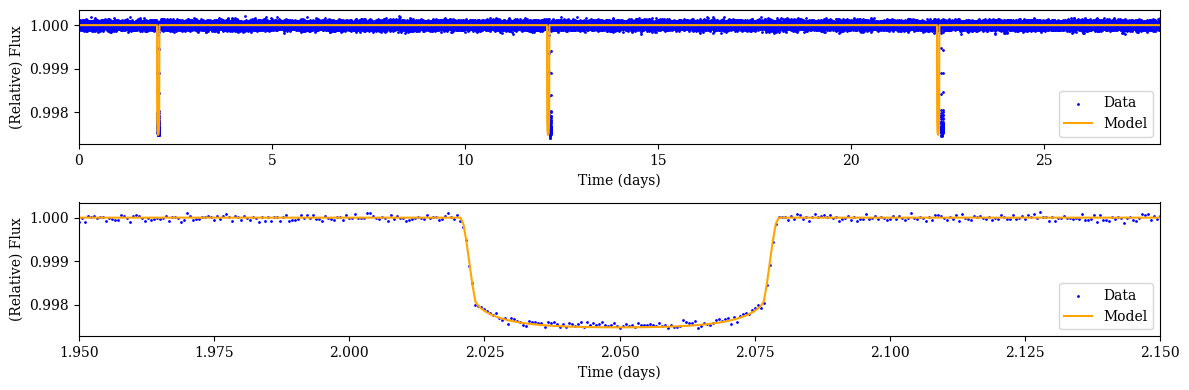

In [7]:
# Compute the model light curve using the previously defined function.
t_model, flux_model = model_light_curve()

# Import NumPy for numerical operations.
import numpy as np

# Import Matplotlib for plotting.
import matplotlib.pyplot as plt

# Set the font family for all plots to serif.
plt.rcParams["font.family"] = "serif"

# Load the observed light curve data from the CSV file.
data = np.loadtxt('HD 1234 Light Curve.csv')

# Extract the observation times.
times_lc = data[0]

# Extract the observed relative flux values.
flux_lc = data[1]

# Create a figure with two vertically stacked subplots.
fig, ax = plt.subplots(nrows = 2, figsize = (12, 4))

# Plot the observed data and the model over the full time range.
ax[0].scatter(times_lc, flux_lc, c = 'blue', s = 1, label = 'Data')
ax[0].plot(t_model, flux_model, c = 'orange', label = 'Model')
ax[0].set_xlabel('Time (days)')
ax[0].set_ylabel('(Relative) Flux')
ax[0].set_xlim(0., 28)

# Plot a zoomed-in view of the transit with both the observed data and the model.
ax[1].scatter(times_lc, flux_lc, c = 'blue', s = 1, label = 'Data')
ax[1].plot(t_model, flux_model, c = 'orange', label = 'Model')
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('(Relative) Flux')
ax[1].set_xlim(1.95, 2.15)

# Add a legend to the first subplot.
ax[0].legend(loc = 'lower right')

# Add a legend to the second subplot.
ax[1].legend(loc = 'lower right')

# Adjust the layout for better spacing.
plt.tight_layout();

So... I missed! As you can see, it's not the WORST fit to the data of all time, but the period of the planet, the epoch, and the radius of the planet at all off. It's on you to fix it!

**Question 1:** Go back to the cell that lists off the parameters of the planet. Change them, then run that cell, then run that cell right above this one to see how the light curve changes. Repeat until you hgave a satisfactory fit to the light curve!

Luckily for us, we’ve also gotten radial velocity measurements of HD 1234 b. The radial velocities of HD 1234 as a function of time are shown below:

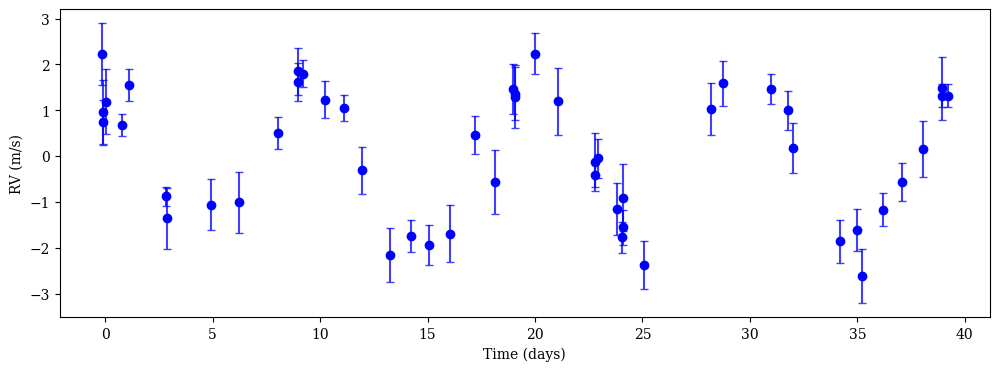

In [8]:
# Load the radial velocity (RV) data from the CSV file.
data_rv = np.loadtxt('HD 1234 RVs.csv')

# Extract the observation times from the first row.
times_rv = data_rv[0]

# Extract the radial velocity measurements from the second row.
rv = data_rv[1]

# Extract the measurement uncertainties from the third row.
rv_err = data_rv[2]

# Create a figure for the plot.
fig, ax = plt.subplots(figsize = (12, 4))

# Plot the radial velocity measurements as a scatter plot.
ax.scatter(times_rv, rv, c = 'blue')

# Add error bars to represent the measurement uncertainties.
ax.errorbar(times_rv, rv, yerr = rv_err, c = 'blue', ls = 'None', capsize = 3, alpha = 0.75)

# Label the x-axis as time in days.
ax.set_xlabel('Time (days)')

# Label the y-axis as radial velocity in meters per second.
ax.set_ylabel('RV (m/s)');

And we do see that sort of sinusoidal shape that we expect from radial velocity signals, which is reassuring! But now, it's time to fit the data.

I've gone ahead and wrote a function below to take in parameters (from the same cell as before), and model the RVs. You can see this function below (ignore how ugly the code is, please!):

In [9]:
# --------------------------------------------------------------------------------------------------
# Parameters of the planet (feel free to change them around and see how the light curve changes!)
# --------------------------------------------------------------------------------------------------
M = 2.4 # the mass of the planet, in Earth masses (note: this should not affect light curves!)
R = 1.05 # the radius of the planet, in Earth radii
P = 10.1 # the period of the planet's orbit, in days
t0 = 2.05 # the epoch of the planet -- meaning the time of the first transit -- in days
inc = 90. # the inclination of the planet, in degrees
e = 0. # the eccentricity of the planet's orbit
w = 0. # the longitude of periastron, in degrees

In [10]:
# Define the maximum allowed eccentricity for numerical stability.
LARGE_ECC = 0.95

# RV (Radial Velocity)

# Compute the radial velocity semi-amplitude (K) from the planet mass.
def mass_to_K(M_p, M_s, per, i, ecc):
    K = np.power(2 * np.pi * 6.67e-11 / (per * 86400.), 1./3.) * ((M_p * 6e24) * np.sin(i * np.pi / 180.) / np.power(M_s * 2e30, 2./3.)) * (1. / np.sqrt(1 - (ecc * ecc)))
    return float(K)

# Define Kepler's equation: f(E) = E − e sin(E) − M.
def f(M, E, e):
    return E - e*np.sin(E) - M

# Define the derivative of Kepler's equation.
def Df(E, e):
        return 1 - e*np.cos(E)

# Solve for the eccentric anomaly using the Newton-Raphson method.
def ecc_anomaly(M, e, tol = 1e-10):
    E0 = M
    fn = f(M, E0, e)

    # Iterate until the solution reaches the desired tolerance.
    while max(np.abs(fn)) > tol:
        E_n = E0 - (f(M, E0, e)/Df(E0, e))
        E0 = E_n
        fn = f(M, E0, e)

    return E0

# Convert observation times into orbital phase.
def phase(t, t0, P):
    return (t-t0)/P

# Compute the radial velocity curve for an eccentric orbit.
def ecc_RV(t, e, omega, K, t0, P):

    # Limit the eccentricity to avoid numerical instability.
    if e > LARGE_ECC:
        e = LARGE_ECC
    if e < (-1 * LARGE_ECC):
        e = -1 * LARGE_ECC
    
    # Compute the orbital phase.
    ph = phase(t, t0, P)

    # Compute the mean anomaly.
    M = 2*np.pi*ph - np.pi/2. - omega
    #M = 2*np.pi*ph + np.pi/2. - omega

    # Compute the eccentric anomaly.
    E = ecc_anomaly(M, e)

    # Compute the true anomaly.
    f = 2*np.arctan((np.sqrt(1+e)/np.sqrt(1-e))*np.tan(E/2.0))

    # Compute the radial velocity at each time.
    RV_t = -K*(np.cos(f + omega) + e*np.cos(omega))

    return RV_t

# Generate the model radial velocity curve.
def model_RVs():

    # Create the model time array.
    ts = np.arange(0, 40, 0.1)

    # Compute the radial velocity semi-amplitude.
    K = mass_to_K(M, 0.2, P, inc, e)

    # Return the model times and radial velocity values.
    return ts, ecc_RV(ts, e, w, K, t0, P)

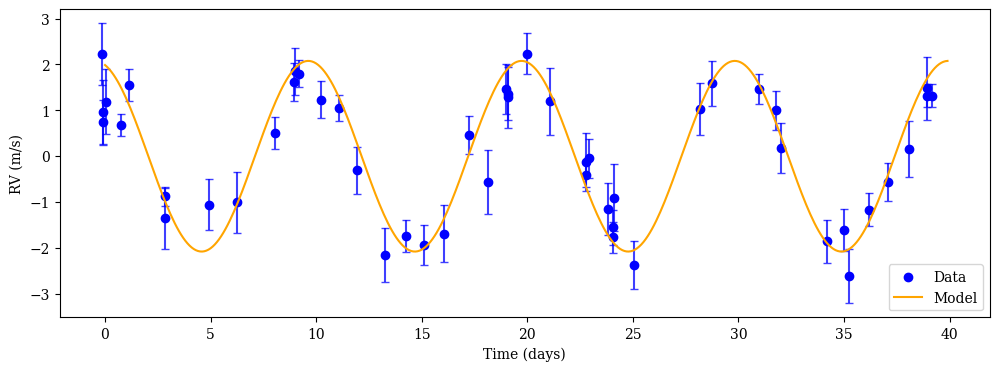

In [11]:
# Generate the model radial velocity curve using the previously defined function.
ts, model_rv = model_RVs()

# Create a figure for the plot.
fig, ax = plt.subplots(figsize = (12, 4))

# Plot the observed radial velocity measurements as a scatter plot.
ax.scatter(times_rv, rv, c = 'blue', label = 'Data')

# Add error bars to represent the measurement uncertainties.
ax.errorbar(times_rv, rv, yerr = rv_err, c = 'blue', ls = 'None', capsize = 3, alpha = 0.75)

# Plot the model radial velocity curve on top of the observed data.
ax.plot(ts, model_rv, c = 'orange', label = 'Model')

# Label the x-axis as time in days.
ax.set_xlabel('Time (days)')

# Label the y-axis as radial velocity in meters per second.
ax.set_ylabel('RV (m/s)')

# Display the legend to distinguish the data from the model.
ax.legend(loc = 'lower right');

So... just like before, it's not the WORST fit in the world, but you can do better. It's on you to fix it!

**Question 2:** Go back to the cell that lists off the parameters of the planet (scroll up!). Change them, then run that cell, then run that cell right above this one to see how the RVs changes. Repeat until you hgave a satisfactory fit to the RVs, and make sure you don't mess up your fit to the light curves in the process!

Now, let's have a few questions interpreting what we did, and our results.

**Question 3:** Below (you may need to run that cell below!), I've included a plot of *mass-radius curves* for different exoplanet compositions -- meaning the relationship between mass and radius for exoplanets of different compositions. (For example, any planet, such as the Earth, which lies close to the "67% Rock, 33% Iron" line probably has a composition of 2/3 rock and 1/3 iron.)

With this in mind: what would you expect this planet to be made of?

*Answer:* 

_**The planet is most likely rocky. Its mass and radius place it close to the 100% rock composition curve, suggesting that it is primarily made of rock with little or no ice.**_

In [12]:
# Import the Image class to display images in a Jupyter Notebook.
from IPython.display import Image

# Import HTML display utilities.
from IPython.core.display import HTML 

# Display the specified image with a width of 800 pixels.
Image(url= "HD1234-M-R.png", width = 800)

**Question 4:** Think about what parameters you had to change to fit the light curves and the radial velocities. What parameters did you need the radial velocities to characterize? What parameters did you need the light curve to characterize?

*Answer:* 

_**The light curve was mainly used to determine the planet's radius because the transit depth depends on the planet's size. The radial velocity data was mainly used to determine the planet's mass because the star's motion depends on the planet's gravitational pull. Both methods also help determine the orbital period.**_

# Part 2 (Optional): Fitting Data Automatically

In this section, we're going to fit the above data with our computers, instead of by hand. This has the advantage of getting much more precise values (and finding error bars on our estimates, too, in the process!)

To do this, we're going to use the package called ``emcee``: https://emcee.readthedocs.io/en/stable/user/install/

In [13]:
#pip install -U emcee

In [14]:
import emcee
import tqdm

We are going to try to fit seven parameters: the mass, radius, period, epoch, inclination, eccentricity, and longitude of periastron:

In [15]:
parameter_names = ['Mass (M_Earth)',
                   'Radius (R_Earth)',
                   'Period (days)',
                   'Epoch (days)',
                   'Inclination (deg)',
                   'Eccentricity',
                   'Long. of Peri. (deg)']

Below is the code for fitting for these parameters! The contents of this code are beyond the scope of this assignment, though feel more than free to try to understand how all of it works (it's very similar to the ``emcee`` tutorial: https://emcee.readthedocs.io/en/stable/tutorials/line/)

(Note that the fit uses the parameters YOU fit for by hand as an 'initial guess' for the computer! So the better you did, the better the model will do, too.)

**Question 5:** Run the cells below to fit for the parameters automatically! (Note that the final cell may take a few minutes -- it took about 5 minutes on my 2021 Macbook Pro, for reference. If you have the ``tqdm`` package installed, you'll see a little progress bar showing how fast it's running, but this isn't necessary to run the code.)

In [16]:
# Compute the total log-likelihood for a given set of model parameters.
def log_likelihood(parameters):
    # Unpack the model parameters.
    m, r, p, ep, incl, ec, lop = parameters

    # ----------------------------
    # Light curve model
    # ----------------------------

    # Compute the semi-major axis using Kepler's third law.
    a = np.cbrt(6.67e-11 * (0.2 * 1.989e30) * np.power(p * 86400., 2) / (4 * np.pi * np.pi)) / 1.39e8

    # Create the transit parameter object.
    params = batman.TransitParams()
    params.t0 = ep                       # Time of inferior conjunction
    params.per = p                       # Orbital period
    params.rp = r * 0.0458               # Planet radius (stellar radii)
    params.a = a                         # Semi-major axis (stellar radii)
    params.inc = incl                    # Orbital inclination
    params.ecc = ec                      # Orbital eccentricity
    params.w = lop                       # Longitude of periastron
    params.u = [0.1, 0.3]                # Limb-darkening coefficients
    params.limb_dark = "quadratic"       # Limb-darkening model

    # Initialize the transit model using the observation times.
    z = batman.TransitModel(params, times_lc)

    # Compute the model light curve.
    flux_model = z.light_curve(params)

    # Compute the light curve log-likelihood.
    lc_ll = -0.5 * np.sum(np.power(flux_lc - flux_model, 2) / np.power(err_lc, 2))

    # ----------------------------
    # Radial velocity model
    # ----------------------------

    # Compute the RV semi-amplitude.
    K = mass_to_K(m, 0.2, p, incl, ec)

    # Generate the model radial velocity curve.
    rv_model = ecc_RV(times_rv, ec, lop, K, ep, p)

    # Compute the radial velocity log-likelihood.
    rv_ll = -0.5 * np.sum(np.power(rv - rv_model, 2) / np.power(rv_err, 2))

    # Return the total log-likelihood.
    return lc_ll + rv_ll

# Define the prior probability for the model parameters.
def log_prior(parameters):
    m, r, p, ep, incl, ec, lop = parameters

    if m < 0 or m > 100:
        return -np.inf
    if r < 0 or r > 100:
        return -np.inf
    if p < 0 or p > 100:
        return -np.inf
    if incl < 0 or incl > 90:
        return -np.inf
    if ec < 0 or ec > 0.9:
        return -np.inf
    if lop < 0 or lop > 360:
        return -np.inf

    # Return a flat prior for valid parameter values.
    return 0.0

# Compute the posterior log-probability.
def log_probability(parameters):

    # Evaluate the prior probability.
    lp = log_prior(parameters)

    # Reject invalid parameter sets.
    if not np.isfinite(lp):
        return -np.inf

    # Posterior = Prior + Likelihood.
    return lp + log_likelihood(parameters)

In [ ]:
# Set the random seed to ensure reproducible results.
np.random.seed(0)

# Convert the inclination to its equivalent angle if it is greater than 90 degrees.
if inc > 90:
    inc_t = 180. - inc
else:
    inc_t = inc

# Generate the initial positions for the MCMC walkers with small random perturbations.
pos = [M, R, P, t0, inc_t, e, w] + 1e-4 * np.random.randn(32, 7)

# Get the number of walkers and the number of model parameters.
nwalkers, ndim = pos.shape

# Create the emcee ensemble sampler.
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability
)

# Set the number of MCMC steps.
nstep = 2000

# Run the MCMC sampler while displaying a progress bar.
sampler.run_mcmc(pos, nstep, progress=True);

 78%|██████████████████████████████████████████████████████████████                 | 1570/2000 [01:56<00:23, 18.35it/s]

Now, we're going to do some diagnostics. This next cell plots the values the computer is fitting to for each of our seven parameters as a function of time. If it's working well, the rightmost ~half of the plots should not really change, where the computer has settled on the best-fit values. If that's NOT the case, change the '2000' in the cell above to a larger number (4000?) to make the computer fit the data for longer and re-run it!

Note: it's totally okay for longitude of periastron specifically to be changing a lot, as you'll see soon!

In [ ]:
# Create one subplot for each model parameter.
fig, axes = plt.subplots(7, figsize=(14, 10), sharex=True)

# Retrieve the MCMC sampling chain.
samples = sampler.get_chain()

# Plot the trace for each model parameter.
for i in range(ndim):
    ax = axes[i]

    # Plot the parameter values from all walkers.
    ax.plot(samples[:, :, i], "k", alpha=0.3)

    # Set the x-axis limits based on the chain length.
    ax.set_xlim(0, len(samples))

    # Label the y-axis with the corresponding parameter name.
    ax.set_ylabel(parameter_names[i], size = 8)

    # Adjust the position of the y-axis label.
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Label the x-axis of the bottom subplot.
axes[-1].set_xlabel("step number");

Now, we can make a *corner plot* of our parameters, in order to see how your parameters can vary, or how they can correlate with each other. You'll need to install the ```corner``` package: https://corner.readthedocs.io/en/latest/install/

In [ ]:
#!pip install corner

In [ ]:
import corner

flat_samples = sampler.get_chain(discard = int(0.5 * nstep), flat = True)
fig = corner.corner(
    flat_samples, labels = parameter_names, quantiles = [0.159, 0.5, 0.841], show_titles = True, title_kwargs={"fontsize": 10},

);

And here's our corner plot! You can see what parameters are correlated with each other.

**Question 6:** What parameters are precisely constrained by our data, and what parameters are not precisely constrained? What parameters are correlated with each other? Why might those parameters be constrained well, or correlated with each other?

*Answer:* 

**_The radius, period, epoch, and inclination are well constrained because their posterior distributions are narrow. The eccentricity and longitude of periastron are not well constrained, since their distributions are much broader. The strongest correlation is between the period and the epoch, because changing one can be partially compensated by changing the other while still fitting the transit timing. The radius is well constrained by the transit depth, while the period and epoch are well constrained by the repeated transit and radial velocity measurements._**